# Free exploration

**Dr. Panagiotis Sakagiannis, Dr. Alexandros Marantis**

## About this notebook

The simplest behavioral experiment there is : put larvae in an empty Petri dish with nothing to
eat, nothing to smell and nowhere to go, and watch what they do anyway.

They do a great deal. A larva with no stimulus alternates bursts of forward crawling with brief
pauses, turning between them, and the resulting path covers the dish in a way that is neither a
straight line nor a random walk. This is **free exploration**, and it matters for two reasons : it
is the behavior every other assay is built on top of, and it is the one the model's motor layer was
calibrated against.

This notebook runs the stored `dish` experiment - a 10 cm circular dish, a population of larvae
placed near the centre with random orientations - and produces the standard set of figures for it.
Nothing is configured here : the experiment already exists, and we only choose how many animals take
part.

**What you will be able to do afterwards**

- Run any stored experiment by name and set your own population size.
- Read what a stored experiment contains without having to build one.
- Find the datasets a run produced and see what is in them.
- Produce the standard exploration figures by calling plots by name.

**Prerequisites** : [Your first simulation](../1_getting_started/single_simulation.ipynb).
No data has to be downloaded.

**Cost** : the simulation below is the whole point of the notebook, so it is on by default. Expect
a few minutes for 20 larvae over the experiment's five simulated minutes.

**Switches in this notebook**

| switch | default | what it turns on |
|---|---|---|
| `RUN_SIMULATION` | `True` | the experiment itself, and therefore every figure below |
| `SAVE_VIDEO` | `False` | a second run that renders the dish to a video file |

## Setup

In [1]:
%matplotlib inline

import larvaworld
from larvaworld.lib import reg
from larvaworld.lib.sim.single_run import ExpRun

larvaworld.VERBOSE = 1

# Tutorial safety switches
RUN_SIMULATION = True  # the point of this notebook; a few minutes of compute
SAVE_VIDEO = False  # re-run with rendering and write a video file

EXPERIMENT = "dish"
N = 20  # larvae; the stored experiment's duration and timestep are left untouched

MEDIA_DIR = "./media/simulated_experiments"
plot_dir = f"{MEDIA_DIR}/{EXPERIMENT}"

Initializing larvaworld registry


Registry configured!


## Section 1 : The experiment

`dish` is one of the experiments that ship with Larvaworld. Everything about it - the arena, who is
in it, how long it lasts, what gets measured - is already decided, and reading it is more useful
here than rebuilding it.

In [2]:
conf = reg.conf.Exp.getID(EXPERIMENT)
env = conf.env_params

print(f"Experiment : {EXPERIMENT}")
print(f"  duration : {conf.duration} min   timestep : {conf.dt} s")
print(
    f"  arena    : {env.arena.geometry}, {[round(x * 1000) for x in env.arena.dims]} mm"
)

sources = env.food_params.source_units
if sources:
    print("  odor sources :")
    for sid, s in sources.items():
        pos_mm = [round(v * 1000, 1) for v in s.pos]
        print(
            f"     {sid:5s} at {pos_mm} mm, odor {s.odor.id!r} "
            f"(intensity {s.odor.intensity}, spread {s.odor.spread:.3f})"
        )
    print(f"  odorscape : {env.odorscape.odorscape}")
else:
    print("  odor sources : none")

for gid, g in conf.larva_groups.items():
    dis = g.distribution
    print(
        f"  larva group {gid!r} : model {g.model if isinstance(g.model, str) else '(inline)'}, "
        f"N={dis.N} placed {dis.mode} around {[round(v * 1000) for v in dis.loc]} mm"
    )

Experiment : dish
  duration : 5.0 min   timestep : 0.1 s
  arena    : circular, [100, 100] mm
  odor sources : none
  larva group 'explorer' : model (inline), N=30 placed uniform around [0, 0] mm


The population is the interesting part. The larvae use the `explorer` model : a crawler and a turner
oscillator, phasically coupled so that bending is suppressed during most of each stride, and an
intermittency module that decides when crawling stops and starts. That is the *intermittent
coupled-oscillator* model of the paper, and its parameters were fitted on recordings of real larvae
exploring exactly this kind of dish.

In [3]:
group_id = conf.larva_groups.keylist[0]
brain = reg.conf.Model.getID("explorer").brain

print("Brain modules of the 'explorer' model :")
for k, v in brain.items():
    if isinstance(v, dict) and "mode" in v:
        print(f"  {k:14s} {v.mode}")
    elif v is None:
        print(f"  {k:14s} -")

Brain modules of the 'explorer' model :
  crawler        realistic
  interference   phasic
  turner         neural
  intermitter    default
  feeder         -
  olfactor       -
  toucher        -
  windsensor     -
  thermosensor   -
  memory         -


## Section 2 : Running it

One call. `experiment=` names the stored experiment, `N=` overrides the population size, and
everything else - duration, timestep, arena, model - comes from the stored configuration.

In [4]:
r = ExpRun(experiment=EXPERIMENT, N=N)

print(f"About to run {EXPERIMENT!r} :")
print(f"  {r.p.duration} min at dt={r.p.dt} s  ->  {r.p.Nsteps} timesteps")
for gid, g in r.p.larva_groups.items():
    print(f"  group {gid!r} : {g.distribution.N} larvae")

About to run 'dish' :
  5.0 min at dt=0.1 s  ->  3000 timesteps
  group 'explorer' : 20 larvae


In [5]:
ds = []
if RUN_SIMULATION:
    r.simulate()
    ds = r.datasets
    for d in ds:
        print(f"{d.id} : {d.config.N} larvae, stored at {d.dir}")
else:
    print("Set RUN_SIMULATION = True to run the experiment.")

--- Simulation dish_44 initialized!--- 
--- Simulation dish_44 : Generating agent groups!--- 



Run time: 0:01:01.348916
Simulation finished
--- Simulation dish_44 completed in 61 seconds!--- 
--- Enriching dataset explorer ---
Vector orientations are already computed. If you want to recompute them, set recompute to True
Angular analysis complete.


Spatial analysis complete.
Dispersal analysis complete.
Dispersal analysis complete.


Tortuosity analysis complete.


Tortuosity analysis complete.


...

Completed bout detection.
Completed bout detection.


Fitted pooled epoch durations.
Completed Lturn bout distribution analysis.
Completed Rturn bout distribution analysis.
Completed Lturn_dur bout distribution analysis.
Completed Rturn_dur bout distribution analysis.
Failed to complete Lturn_amp bout distribution analysis.
Completed Rturn_amp bout distribution analysis.
Completed turn_dur bout distribution analysis.
Failed to complete turn_amp bout distribution analysis.
Failed to complete turn_vel_max bout distribution analysis.
Completed vel_minima bout distribution analysis.
Completed vel_maxima bout distribution analysis.
Completed stride bout distribution analysis.
Completed exec bout distribution analysis.
Completed run_count bout distribution analysis.
Completed stride_Dor bout distribution analysis.
Completed stride_dur bout distribution analysis.
Completed stride_dst bout distribution analysis.
Completed stride_idx bout distribution analysis.
Completed run_dur bout distribution analysis.
Completed run_dst bout distribution analy

Computed average curves during stridecycle for diverse parameters.
Completed stridecycle interference analysis.
--- Dataset explorer enriched ---
--------------------------------


***** Dataset explorer stored.-----
Simulation dish_44 stored in directory C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dish/dish_44


explorer : 20 larvae, stored at C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dish/dish_44/data/explorer


The same run can be rendered instead of only recorded. This repeats the simulation with the
visualization on and writes a video file, which is how the population figures of the paper were
produced.

In [6]:
if SAVE_VIDEO:
    r_vid = ExpRun(
        experiment=EXPERIMENT,
        N=N,
        screen_kws={
            "vis_mode": "video",
            "show_display": False,
            "save_video": True,
            "media_dir": MEDIA_DIR,
            "video_file": "free_exploration",
            "visible_trails": True,
        },
    )
    r_vid.simulate()
    print(f"Video written to {MEDIA_DIR}/free_exploration.mp4")
else:
    print("Set SAVE_VIDEO = True to render this experiment to a video file.")

Set SAVE_VIDEO = True to render this experiment to a video file.


## Section 3 : What came out

A simulated dataset is the same object an imported recording is : a timeseries `s`, one endpoint row
per animal in `e`, and the configuration `c` that produced them. Every metric requested by the
experiment's enrichment - angular and spatial kinematics, stride and pause annotation, dispersal -
has already been computed by the time the run returns.

In [7]:
if ds:
    d = ds[0]
    s, e, c = d.data
    print(f"dataset {d.id!r}")
    print(f"  timeseries : {s.shape[0]} rows x {s.shape[1]} columns")
    print(f"  endpoint   : {e.shape[0]} rows x {e.shape[1]} columns")
    print(f"  timestep   : {c.dt} s over {round(c.duration, 1)} min")

dataset 'explorer'
  timeseries : 60020 rows x 44 columns
  endpoint   : 20 rows x 143 columns
  timestep   : 0.1 s over 5.0 min


In [8]:
if ds:
    display(
        ds[0]
        .e[
            [
                "length",
                "cum_dur",
                "cum_dst",
                "num_strides",
                "run_dur_ratio",
                "pause_dur_ratio",
            ]
        ]
        .describe()
        .round(4)
    )

,length,cum_dur,cum_dst,num_strides,run_dur_ratio,pause_dur_ratio
count,20.000,20.0,20.0000,20.0000,20.0000,20.0000
mean,0.005,300.0,0.4052,350.3500,0.8679,0.1192
std,0.000,0.0,0.0182,14.6189,0.0323,0.0306
min,0.005,300.0,0.3755,325.0000,0.7993,0.0737
25%,0.005,300.0,0.3935,339.7500,0.8458,0.0948
50%,0.005,300.0,0.4045,351.5000,0.8733,0.1165
75%,0.005,300.0,0.4164,360.0000,0.8943,0.1415
max,0.005,300.0,0.4437,375.0000,0.9143,0.1830


Two of those columns say most of what free exploration is about : `run_dur_ratio` and
`pause_dur_ratio`, the fraction of the experiment each larva spent crawling and pausing. Real
third-instar larvae spend roughly 80-90 % of their time crawling, and the intermittency module is
what puts the model in that range. `num_strides` counts the peristaltic strides each animal made -
one of the three distributions the paper compares against real larvae.

## Section 4 : The analysis

Every stored experiment knows which figures belong to it. `ExpRun.analyze()` looks the experiment up,
runs the plots registered for that kind of assay, writes them next to the datasets, and returns them
grouped by topic in `r.figs`. Nothing has to be chosen by hand.

In [9]:
if RUN_SIMULATION:
    r.analyze()
    print("Figure groups produced :")
    for gname, group in r.figs.items():
        print(f"  {gname:12s} {list(group)}")
    print()
    print(f"All of them were also written to {r.plot_dir}")

Plot comparative_trajectories_default.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dish/dish_44/plots/traj\comparative_trajectories_default.pdf


Plot aligned2origin.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dish/dish_44/plots/traj\aligned2origin.pdf


Plot runsNpauses.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dish/dish_44/plots/general\runsNpauses.pdf


Plot end_box_basic.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dish/dish_44/plots/endpoint\end_box_basic.pdf


Plot end_box_basic.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dish/dish_44/plots/endpoint\end_box_basic.pdf


...

Plot ang_pars.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dish/dish_44/plots/distro\ang_pars.pdf


Plot stride_cycle_curves.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dish/dish_44/plots/stride\stride_cycle_curves.pdf


Plot stride_cycle_curves_all_larvae.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dish/dish_44/plots/stride\stride_cycle_curves_all_larvae.pdf


Plot annotated_strideplot.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dish/dish_44/plots/track\annotated_strideplot.pdf


Plot annotated_turnplot.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dish/dish_44/plots/track\annotated_turnplot.pdf
Figure groups produced :
  traj         ['trajectories', 'aligned2origin']
  general      ['epochs']
  endpoint     ['endpoint box', 'crawl pars']
  distro       ['distros', 'angular pars']
  stride       ['stride cycle']
  track        ['stride track', 'turn track']

All of them were also written to C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/dish/dish_44/plots


`r.figs` holds the figure objects themselves, so they can be shown here one group at a time.

In [10]:
def show(group):
    """Display every figure of one analysis group."""
    if not RUN_SIMULATION or group not in r.figs:
        return
    for name, fig in r.figs[group].items():
        print(name)
        display(fig)

### The paths

What the animals actually did, and the same paths translated to a common origin. Removing the
arbitrary starting position makes the *shape and extent* of the tracks comparable, which is what the
next notebook measures properly.

trajectories


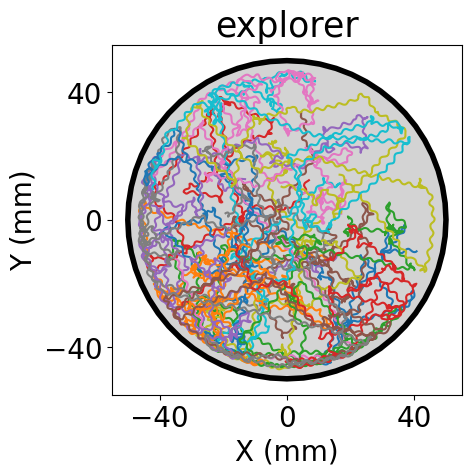

aligned2origin


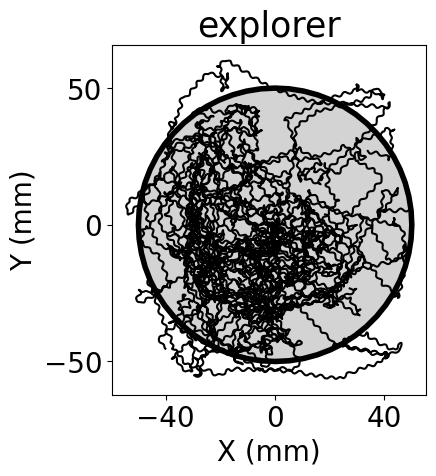

In [11]:
show("traj")

### Runs and pauses

Crawling is not continuous. This figure shows the distributions of stridechain length and pause
duration - the intermittency the paper found to be best described by log-normal distributions, and
the reason a virtual larva's path looks like a real one rather than like a smooth curve.

epochs


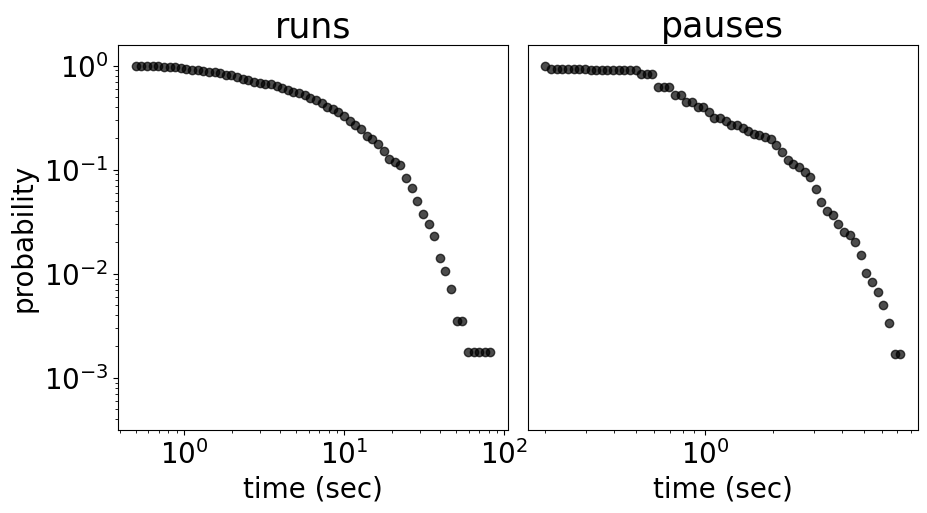

In [12]:
show("general")

### One value per animal

Endpoint metrics summarize each larva's whole track in a single number, so the boxplots show how
much the individuals of the population differ from one another. The second figure is the crawling
side of it : stride length, frequency and speed.

endpoint box


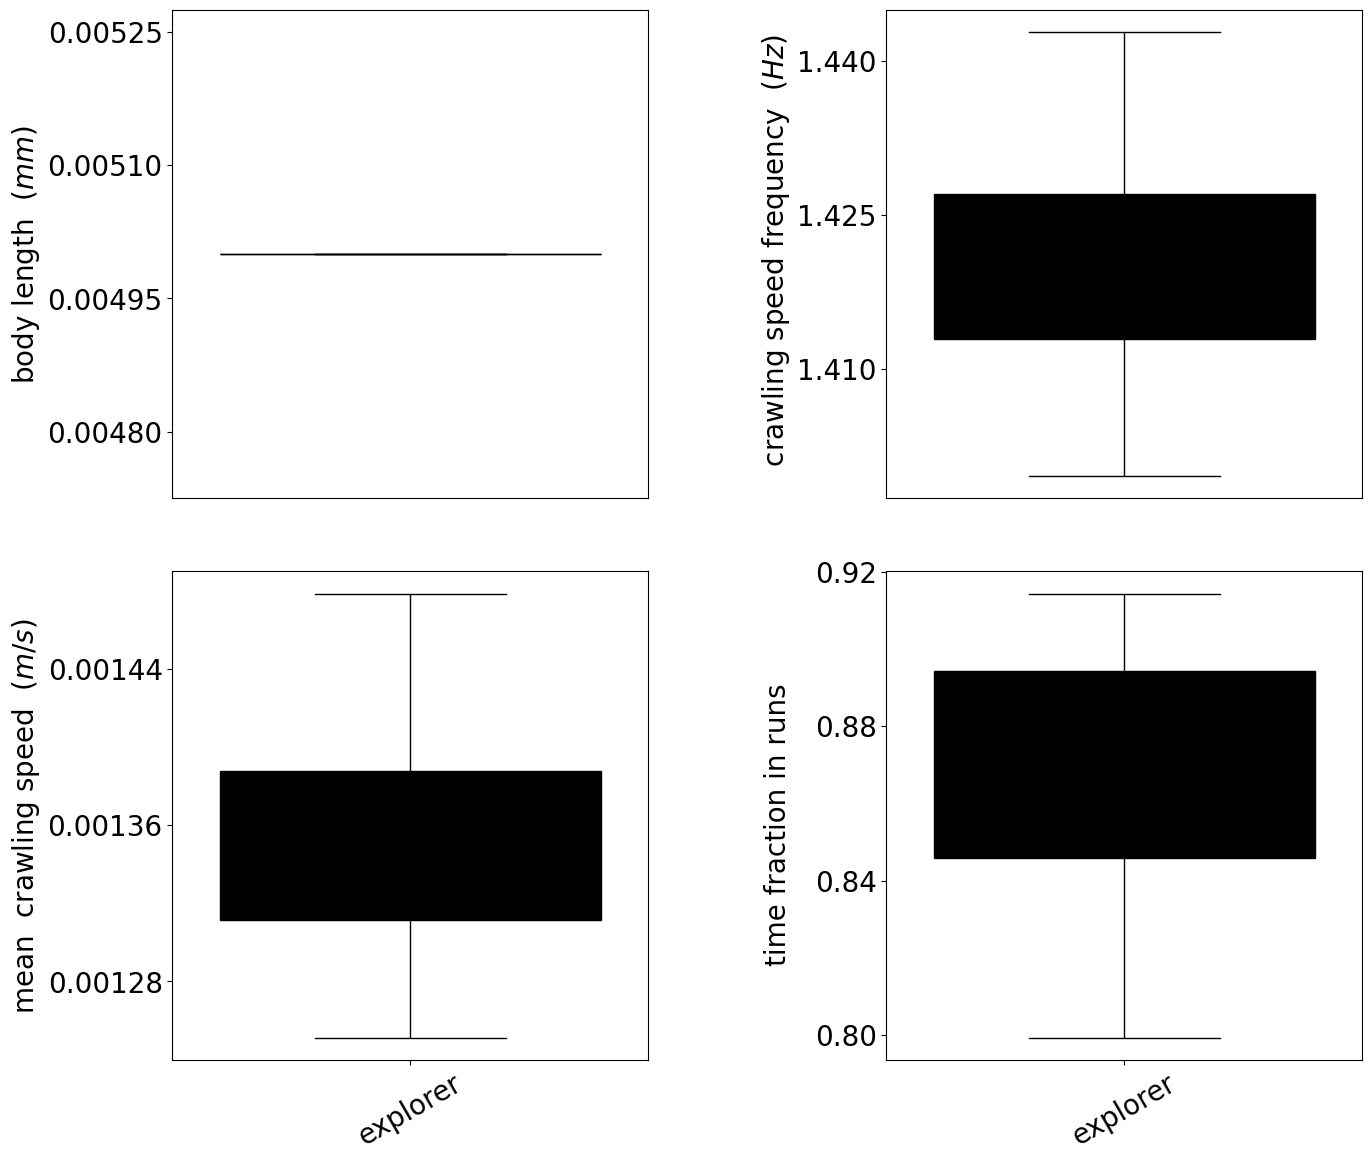

crawl pars


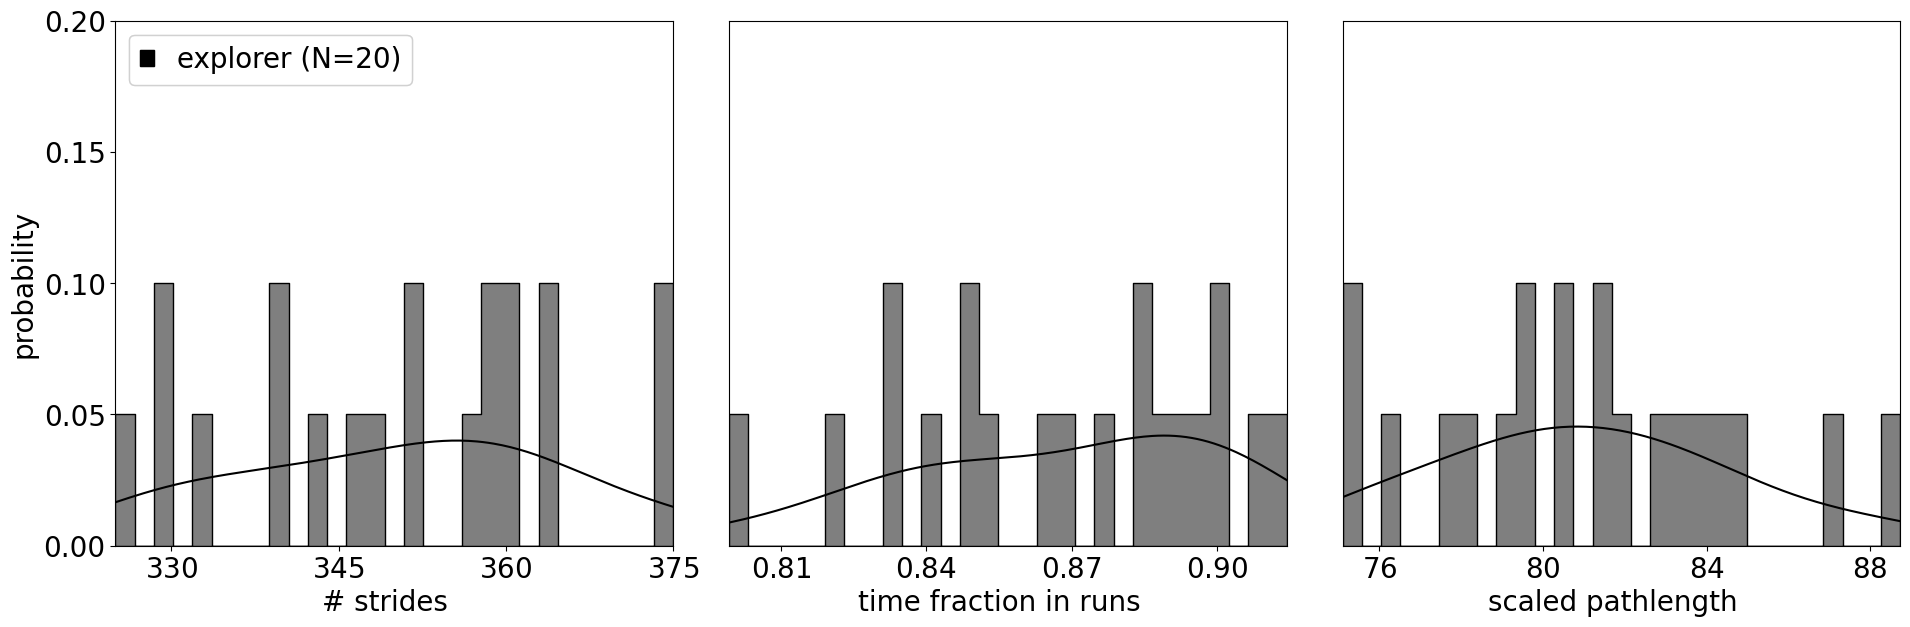

In [13]:
show("endpoint")

### Distributions

The same quantities as full distributions rather than summaries, and the angular parameters that
describe the lateral bending which steers the animal.

distros


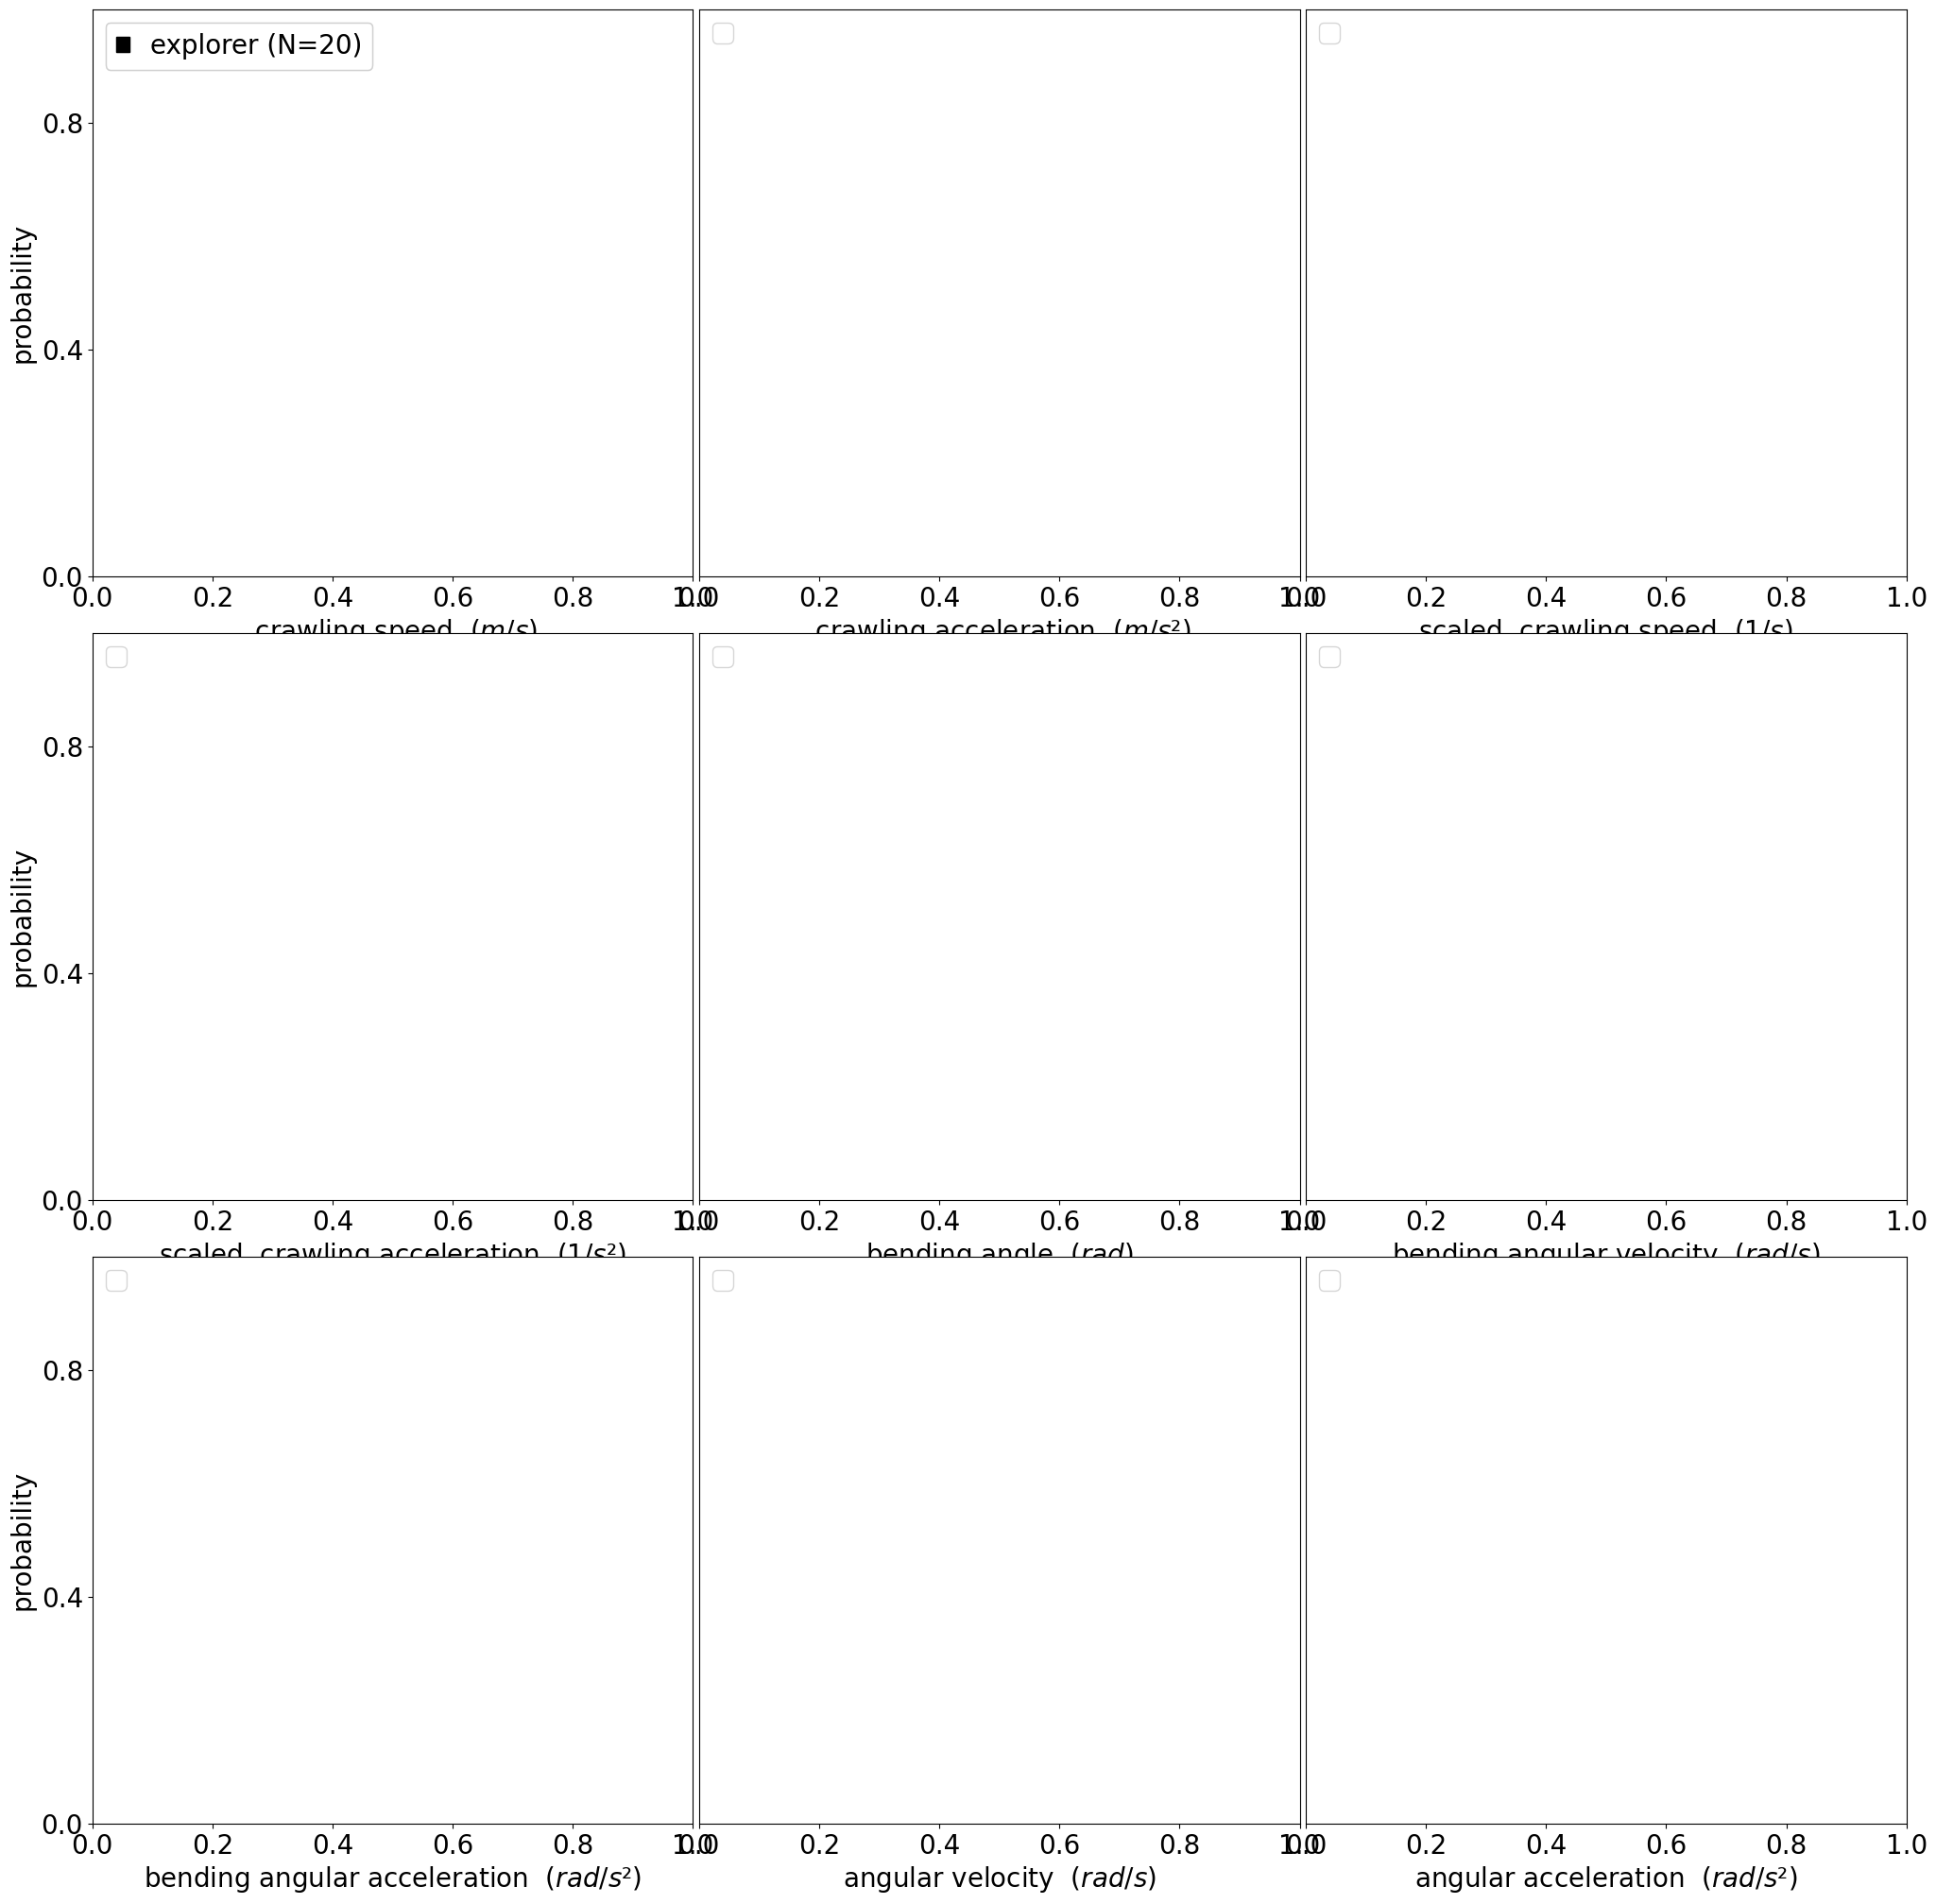

angular pars


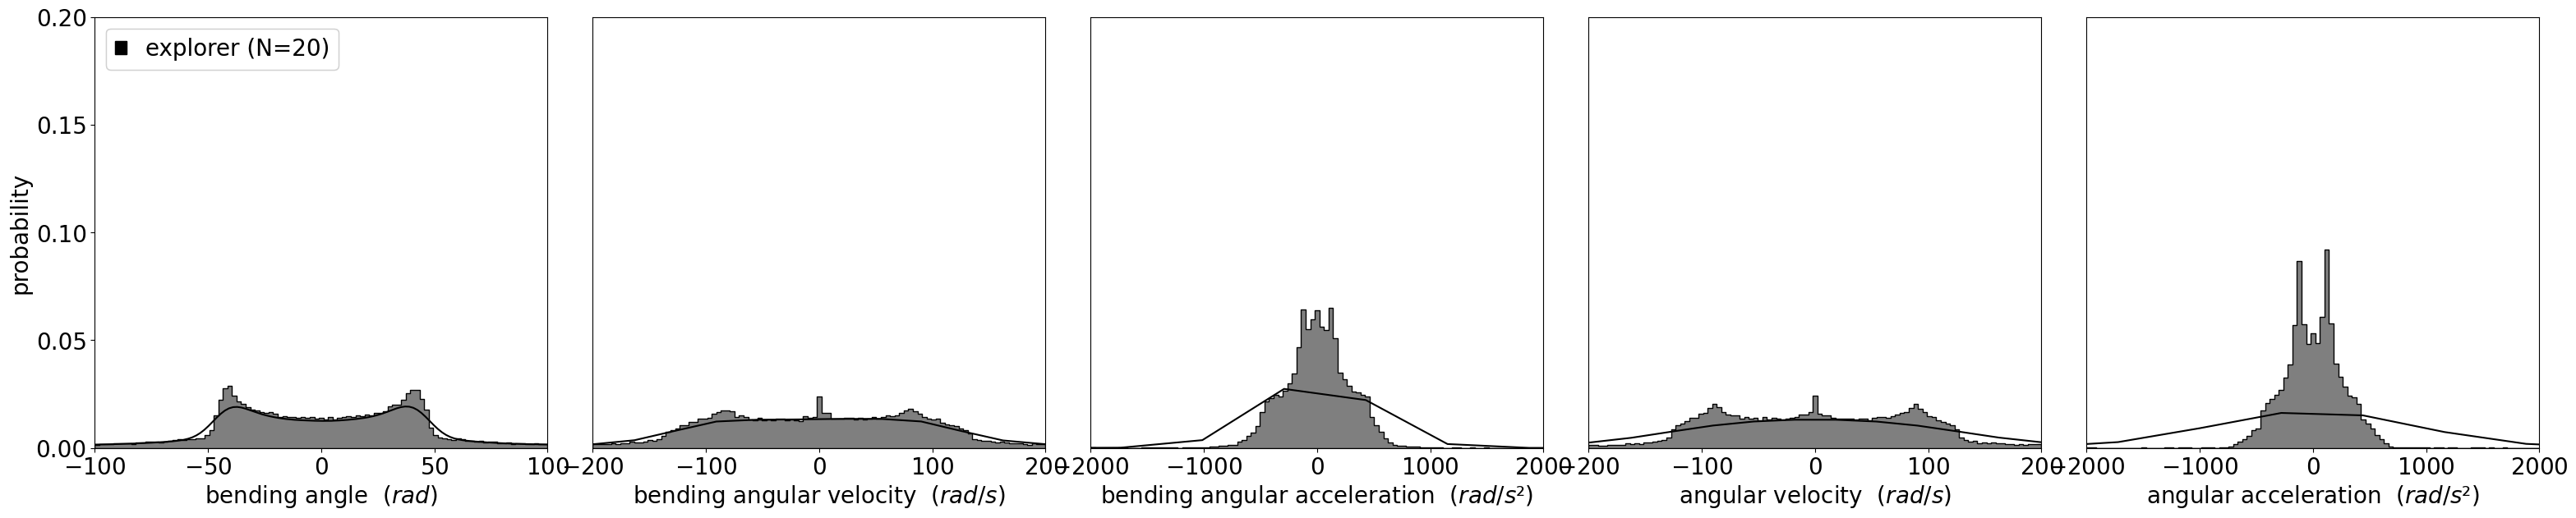

In [14]:
show("distro")

### The stride cycle

Every detected stride, interpolated onto a common cycle and averaged. This is the waveform of
Figure 3C-D of the paper : forward velocity peaking once per cycle, and angular velocity
suppressed over most of it - the crawl-bend interference that couples the two oscillators.

stride cycle


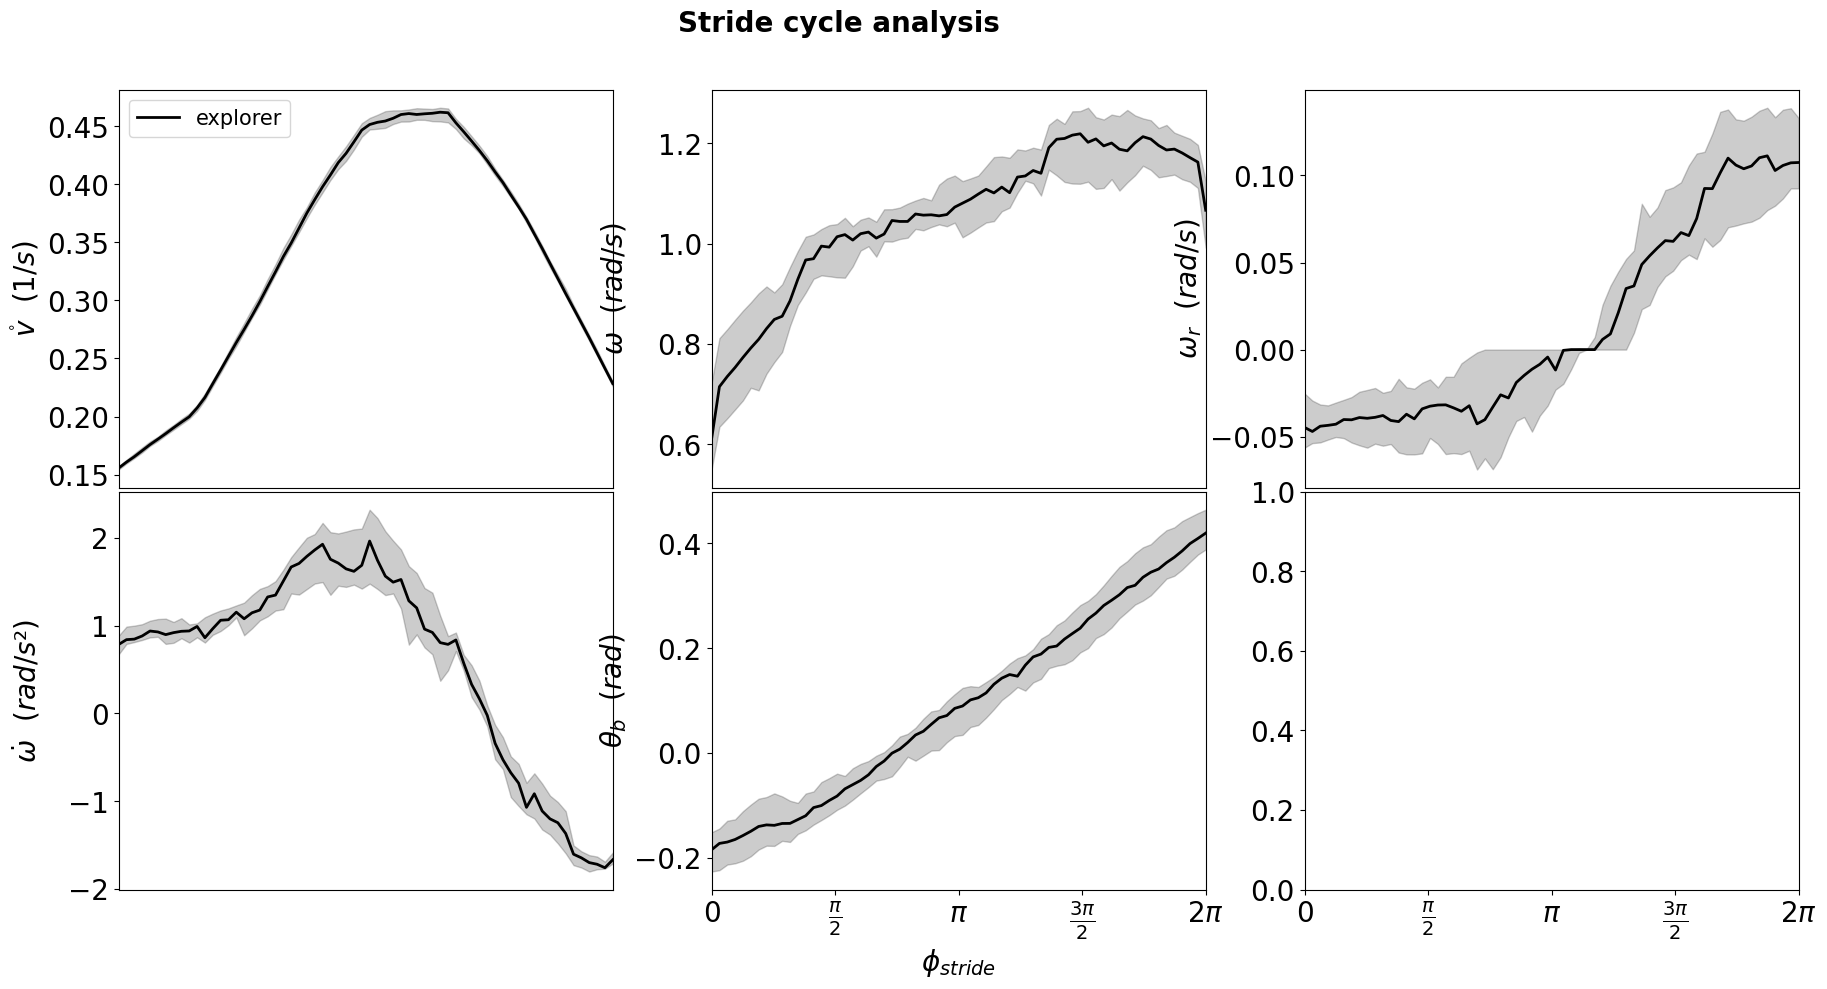

In [15]:
show("stride")

### Individual tracks, annotated

Zooming from distributions down to single events. Each panel is one larva's velocity over a minute
of the experiment, with the detected strides and turns marked on it. This is the quickest way to
check that the bout annotation behaves sensibly on your data.

stride track


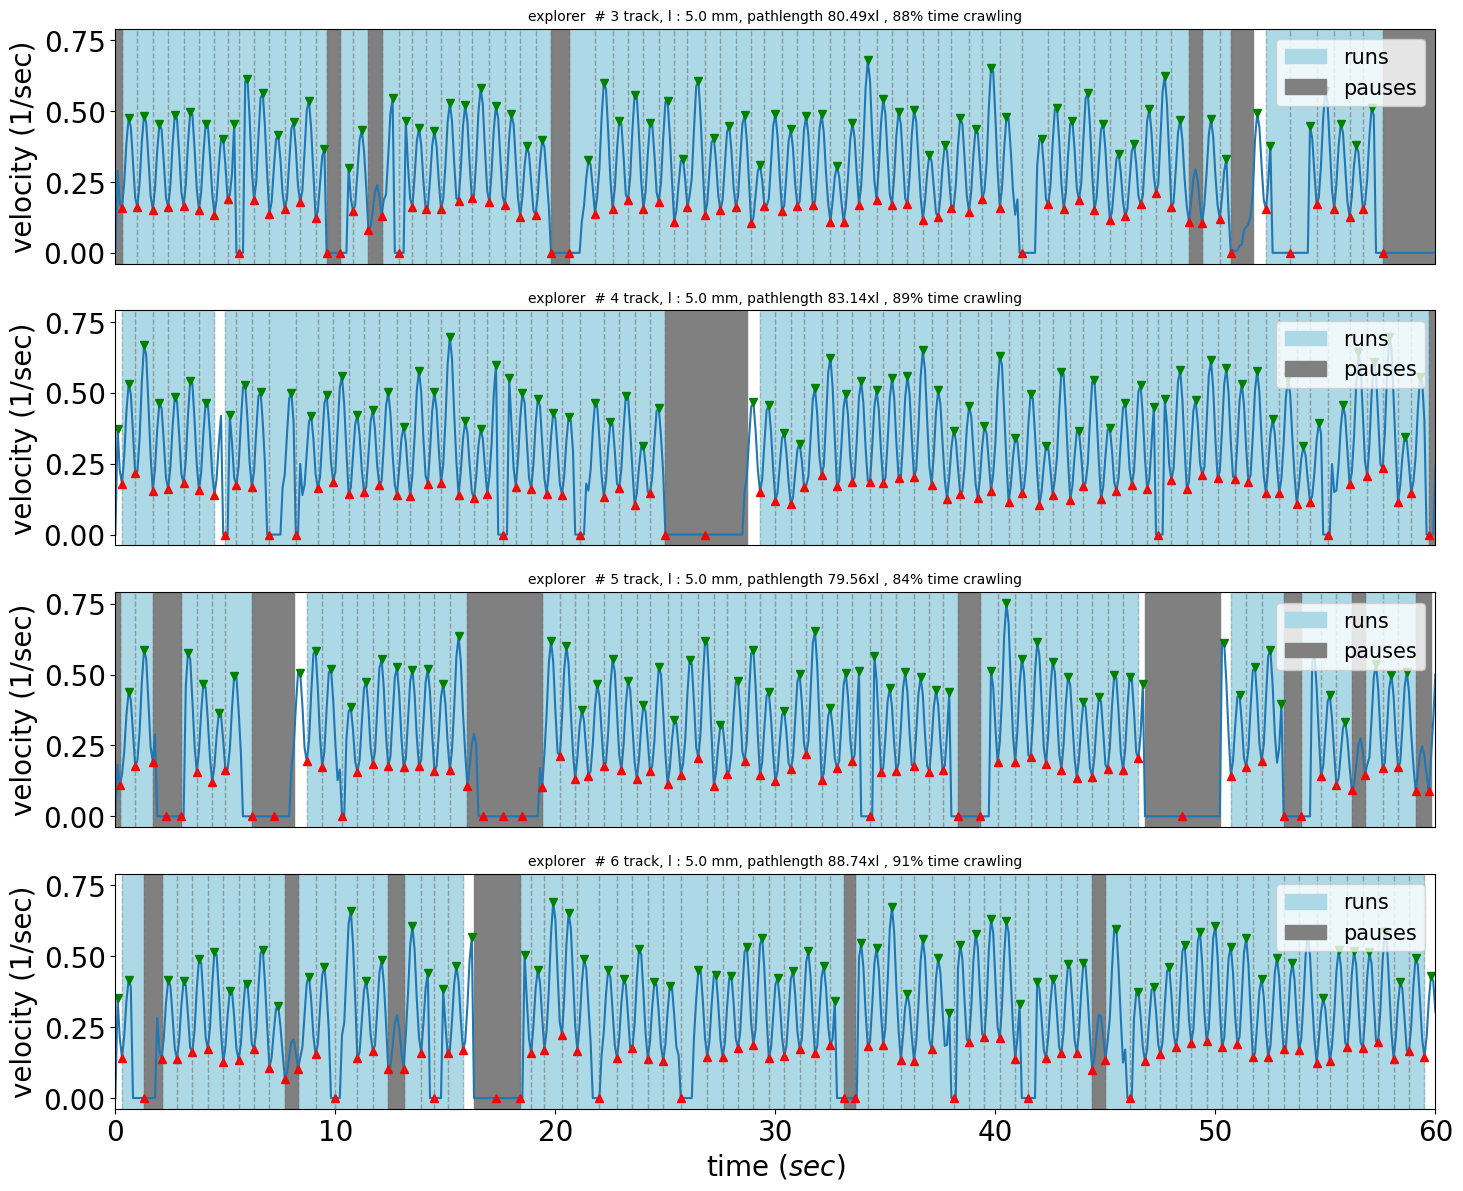

turn track


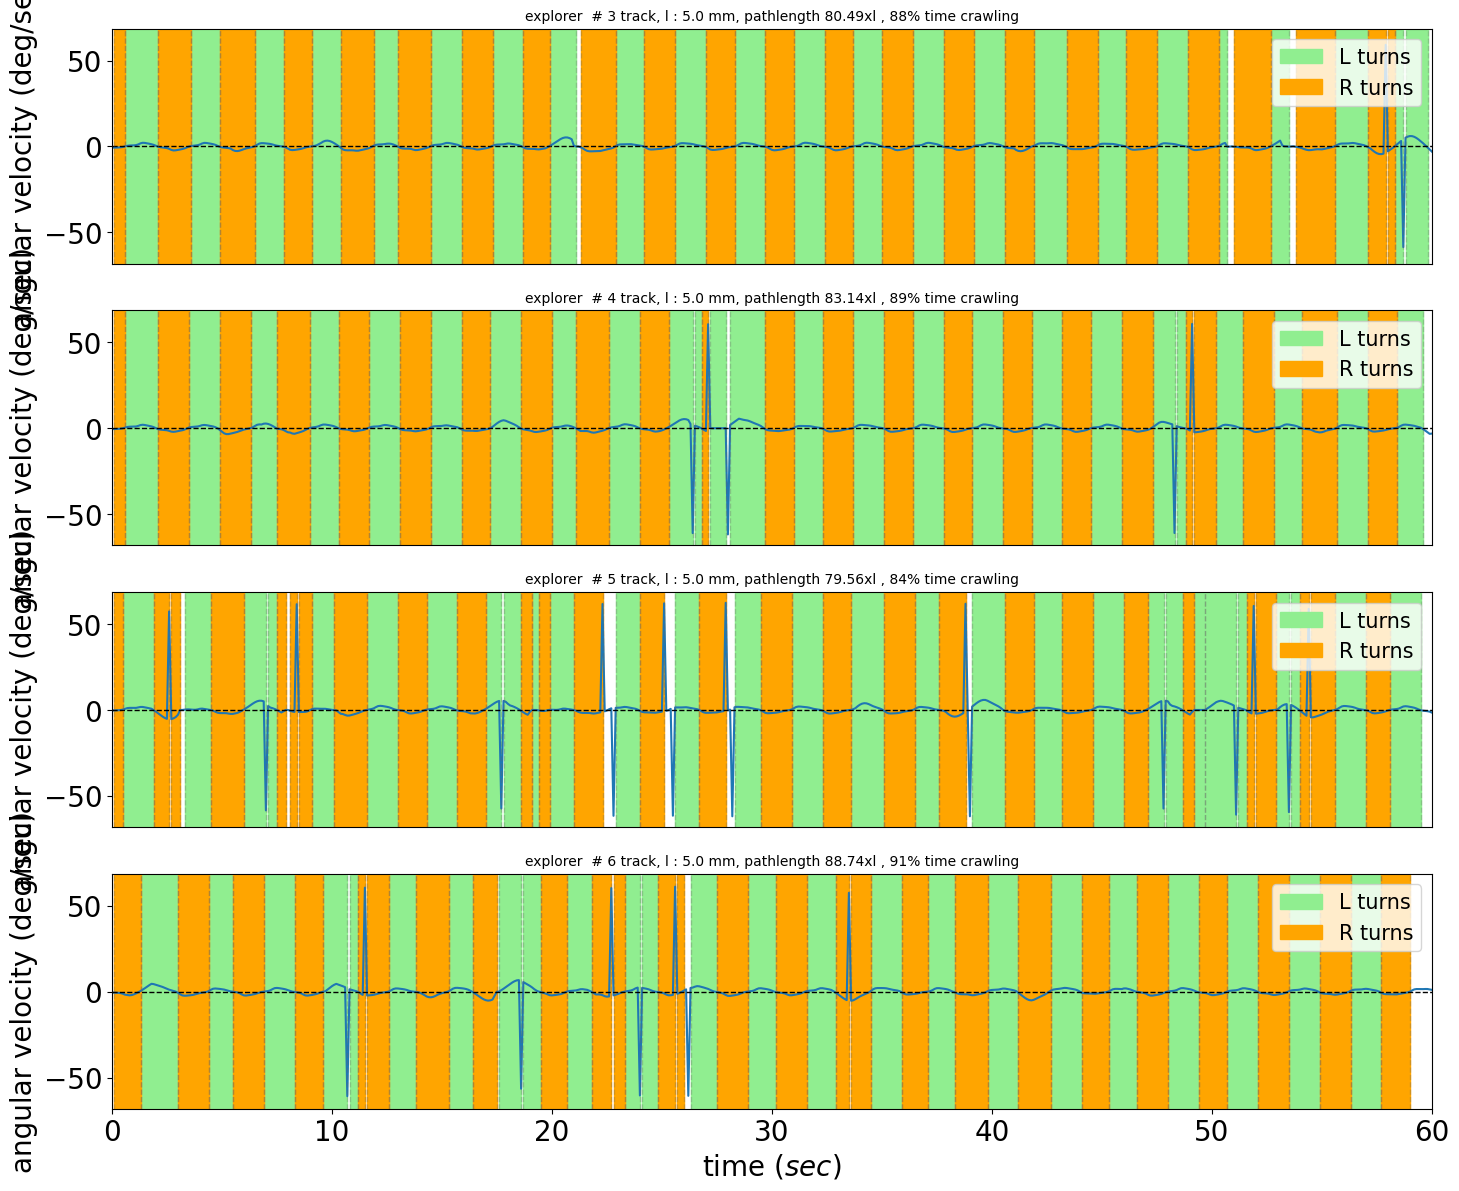

In [16]:
show("track")

## What the paper reports

This assay is the *Exploration* section of Sakagiannis et al. (2025). Two things there are worth
carrying back to the figures above.

**The model is the figures.** The paper's Figure 1B is the architecture the `explorer` model
implements : a crawler oscillator and a turner oscillator, phasically coupled so that bending is
attenuated over most of the stride cycle, with an intermittency module switching crawling on and
off. Figure 3 shows the empirical measurements that shape it - a crawling rhythm near 1.4 Hz, a
slower bending rhythm near 0.4 Hz, and log-normal stridechain and pause distributions. Table 1 lists
the calibrated parameter values; the stored `explorer` model carries its own calibration and is
close to, but not identical with, that table.

**The scale here is smaller.** The paper simulates 200 larvae for 3 minutes at a 1/16 s timestep in
a large arena, because it is after population statistics. The stored `dish` experiment is a 10 cm
dish at a 0.1 s timestep, which is the right size for a laptop and the wrong size for measuring
dispersal - larvae reach the wall. That is exactly what the [next
notebook](dispersion.ipynb) fixes.

The paper is also explicit that this short-horizon exploration is not the whole story : long-horizon
dispersal statistics of the kind reported by Sims et al. (2019) would need larger or unbounded
arenas.

## Where to go next

- [Dispersal](dispersion.ipynb) - the same animals, measured properly, and compared against real
  larvae.
- [Chemotaxis](chemotaxis.ipynb) - what happens once there is something to smell.
- [Your first simulation](../1_getting_started/single_simulation.ipynb) - the launcher used here, in
  more detail.
- Reference : [Single experiments](../../working_with_larvaworld/single_experiments.md) and
  [Experiment types](../../concepts/experiment_types.md).

## References

> Sakagiannis PP, Jürgensen AM, Nawrot MP. 2025. *A behavioral architecture for realistic
simulations of Drosophila larva locomotion and foraging.* eLife 14:RP104262.
<https://doi.org/10.7554/eLife.104262>

> Sakagiannis PP, Rapp H, Jovanic T, Nawrot MP. 2025. *Larvaworld: a behavioral simulation and
analysis platform for Drosophila larva.* bioRxiv.
<https://doi.org/10.1101/2025.06.15.659765>

> Sims DW, Humphries NE, Hu N, Medan V, Berni J. 2019. *Optimal searching behaviour generated
intrinsically by the central pattern generator for locomotion.* eLife 8:e50316.
<https://doi.org/10.7554/eLife.50316>